# What is HITL

**HITL (Human-in-the-Loop)** is a design approch in AI systems where a human actively participates at critical points of the AI workflow - either to **supervise**, **approve**, **correct**, or **guide** the model's output.

Think of HITL as putting a human "checkpoint" inside an AI pipeline so that important decisions are not made autonomously by the model.

# Why HITL Exists ?
1. To help agentic systems
2. To add accountability

**HITL ensures**:
- Accuracy
- Safety
- Ethical Alignment
- Better user experience

**Common HITL Patters**:
- Action Approval Patter (Approve/ Reject Before Execution)
- Output Review/ Edit Pattern
- Ambiguity Clarification Pattern
- Escalation Pattern

In [1]:
from typing import Annotated, TypedDict

from langchain_ollama import ChatOllama
from langchain_core.messages import AnyMessage, AIMessage, BaseMessage

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.checkpoint.memory import MemorySaver
from langgraph.types import interrupt, Command

from dotenv import load_dotenv


In [2]:
load_dotenv()

True

In [3]:
llm = ChatOllama(model="llama3.1:8b")

In [4]:
class ChatState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]

In [5]:
def chat_node(state: ChatState):

    decision = interrupt({
        "type": "approval",
        "reason": "Model is about to answer a user question",
        "question": state["messages"][-1].content,
        "instruction": "Approve this question? yes/no"
    })

    if decision["approved"] == "no":
        return {"messages": [AIMessage(content="Not Approved.")]}

    else:
        response = llm.invoke(state["messages"])
        return {"messages": [response]}
    
    

In [6]:
# defining Graph
graph = StateGraph(ChatState)

# adding nodes
graph.add_node("chat", chat_node)

# defining edge
graph.add_edge(START, "chat")
graph.add_edge("chat", END)

# checkpointer is required for interrupts
checkpointer = MemorySaver()

# compile the app
workflow = graph.compile(checkpointer=checkpointer)

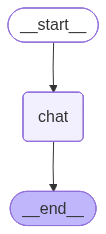

In [7]:
workflow

In [8]:
initial_state = {"messages": "What is my name"}

In [9]:
config = {"configurable": {"thread_id": "1"}}

In [10]:
final_state = workflow.invoke(initial_state, config=config)

In [11]:
final_state

{'messages': [HumanMessage(content='What is my name', additional_kwargs={}, response_metadata={}, id='aa9bbe38-213b-4722-8079-b26f2da2e7f7')],
 '__interrupt__': [Interrupt(value={'type': 'approval', 'reason': 'Model is about to answer a user question', 'question': 'What is my name', 'instruction': 'Approve this question? yes/no'}, id='a597f5356be8d2b13ea3ad188fb8c343')]}

In [12]:
final_state['__interrupt__'][0].value

{'type': 'approval',
 'reason': 'Model is about to answer a user question',
 'question': 'What is my name',
 'instruction': 'Approve this question? yes/no'}

In [13]:
user_input = 'yes'

In [16]:
# result the interrupted flow
final_result = workflow.invoke(
    Command(resume={"approved": user_input}),
    config=config
)

In [17]:
final_result

{'messages': [HumanMessage(content='What is my name', additional_kwargs={}, response_metadata={}, id='aa9bbe38-213b-4722-8079-b26f2da2e7f7'),
  AIMessage(content="Unfortunately, I'm a large language model, I don't have any information about your personal identity or name. This conversation just started, and I don't have the ability to access any external information about you.\n\nIf you'd like to share your name with me, I'd be happy to chat with you!", additional_kwargs={}, response_metadata={'model': 'llama3.1:8b', 'created_at': '2026-03-02T10:46:31.8190615Z', 'done': True, 'done_reason': 'stop', 'total_duration': 26349862900, 'load_duration': 12700726200, 'prompt_eval_count': 14, 'prompt_eval_duration': 856007400, 'eval_count': 63, 'eval_duration': 12711768900, 'logprobs': None, 'model_name': 'llama3.1:8b', 'model_provider': 'ollama'}, id='lc_run--019cae27-bb84-71d0-afa0-afd415870e56-0', usage_metadata={'input_tokens': 14, 'output_tokens': 63, 'total_tokens': 77})]}

In [61]:
# backend.py

from langgraph.graph import StateGraph, START
from typing import TypedDict, Annotated
from langchain_core.messages import BaseMessage, HumanMessage
from langchain_openai import ChatOpenAI
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition
from langchain_core.tools import tool
from langgraph.types import interrupt, Command
from dotenv import load_dotenv
import requests

load_dotenv()

# -------------------
# 1. LLM
# -------------------
from langchain_ollama import  ChatOllama
llm = ChatOllama(model="llama3.1:8b")

# -------------------
# 2. Tools
# -------------------
@tool
def get_stock_price(symbol: str) -> dict:
    """
    Fetch latest stock price for a given symbol (e.g. 'AAPL', 'TSLA') 
    using Alpha Vantage with API key in the URL.
    """
    url = (
        "https://www.alphavantage.co/query"
        f"?function=GLOBAL_QUOTE&symbol={symbol}&apikey=C9PE94QUEW9VWGFM"
    )
    r = requests.get(url)
    return r.json()


@tool
def purchase_stock(symbol: str, quantity: int) -> dict:
    """
    Simulate purchasing a given quantity of a stock symbol.

    HUMAN-IN-THE-LOOP:
    Before confirming the purchase, this tool will interrupt
    and wait for a human decision ("yes" / anything else).
    """
    # This pauses the graph and returns control to the caller
    decision = interrupt(f"Approve buying {quantity} shares of {symbol}? (yes/no)")

    if isinstance(decision, str) and decision.lower() == "yes":
        return {
            "status": "success",
            "message": f"Purchase order placed for {quantity} shares of {symbol}.",
            "symbol": symbol,
            "quantity": quantity,
        }
    
    else:
        return {
            "status": "cancelled",
            "message": f"Purchase of {quantity} shares of {symbol} was declined by human.",
            "symbol": symbol,
            "quantity": quantity,
        }


tools = [get_stock_price, purchase_stock]
llm_with_tools = llm.bind_tools(tools)

# -------------------
# 3. State
# -------------------
class ChatState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]

# -------------------
# 4. Nodes
# -------------------
def chat_node(state: ChatState):
    """LLM node that may answer or request a tool call."""
    messages = state["messages"]
    response = llm_with_tools.invoke(messages)
    return {"messages": [response]}

tool_node = ToolNode(tools)

# -------------------
# 5. Checkpointer (in-memory)
# -------------------
memory = MemorySaver()

# -------------------
# 6. Graph
# -------------------
graph = StateGraph(ChatState)
graph.add_node("chat_node", chat_node)
graph.add_node("tools", tool_node)

graph.add_edge(START, "chat_node")

graph.add_conditional_edges("chat_node", tools_condition)
graph.add_edge("tools", "chat_node")

chatbot = graph.compile(checkpointer=memory)

# -------------------
# 7. Simple usage example (CLI with HITL)
# -------------------
if __name__ == "__main__":
    
    # Use a fixed thread_id so the conversation is persisted in memory
    thread_id = "demo-thread"

    while True:
        user_input = input("You: ")
        if user_input.lower().strip() in {"exit", "quit"}:
            print("Goodbye!")
            break

        # Build initial state for this turn
        state = {"messages": [HumanMessage(content=user_input)]}

        # Run the graph (may hit an interrupt)
        result = chatbot.invoke(
            state,
            config={"configurable": {"thread_id": thread_id}},
        )

        # Check for HITL interrupt from purchase_stock
        interrupts = result.get("__interrupt__", [])

        if interrupts:
            # Our interrupt payload is the string we passed to interrupt(...)
            prompt_to_human = interrupts[0].value
            print(f"HITL: {prompt_to_human}")
            decision = input("Your decision: ").strip().lower()

            # Resume graph with the human decision ("yes" / "no" / whatever)
            result = chatbot.invoke(
                Command(resume=decision),
                config={"configurable": {"thread_id": thread_id}},
            )

        # Get the latest message from the assistant
        messages = result["messages"]
        last_msg = messages[-1]
        print(f"Bot: {last_msg.content}\n")

You:  hi


Bot: The current stock price of Apple (AAPL) is $260.58 per share, with a volume of 30,845,294 shares traded on the latest trading day. The stock has decreased by $3.77, or -1.43%, from its previous close.



KeyboardInterrupt: Interrupted by user